# Prediksi Biaya Asuransi Kesehatan

Notebook ini membangun model **regresi** untuk memprediksi biaya asuransi kesehatan (`charges`) 
berdasarkan profil seseorang: umur, jenis kelamin, BMI, jumlah anak, status merokok, dan wilayah tempat tinggal.

**Dataset:** Medical Insurance Cost Dataset  
**Tipe Masalah:** Regresi (prediksi angka kontinu)  
**Model yang dibandingkan:** Linear Regression, Decision Tree, Random Forest, Gradient Boosting

---


## 1. Import Library

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib



## 2. Load Data & Eksplorasi Awal

In [3]:
df = pd.read_csv('data/medical_insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   str    
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   str    
 5   region    2772 non-null   str    
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 195.5 KB


## 3. Cek Data Hilang & Duplikat

In [5]:
missing_value = df.isnull().sum()
duplicated_value = df.duplicated().sum()
print(f'\n_____ Nilai kosong : \n{missing_value}')
print(f'_____ Nilai duplikat : {duplicated_value}')


_____ Nilai kosong : 
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
_____ Nilai duplikat : 1435


> **Catatan:** Dataset asli "Medical Insurance Cost" hanya memiliki ±1.337 baris unik. 
> Jika jumlah baris kamu lebih besar dari itu, kemungkinan ada duplikasi yang perlu dihapus.

In [6]:
print(f'Nilai sebelum dihapus : {len(df)}')
df = df.drop_duplicates()
print(f'Nilai setelah dihapus : {len(df)}')

Nilai sebelum dihapus : 2772
Nilai setelah dihapus : 1337


## 4. Exploratory Data Analysis (EDA)

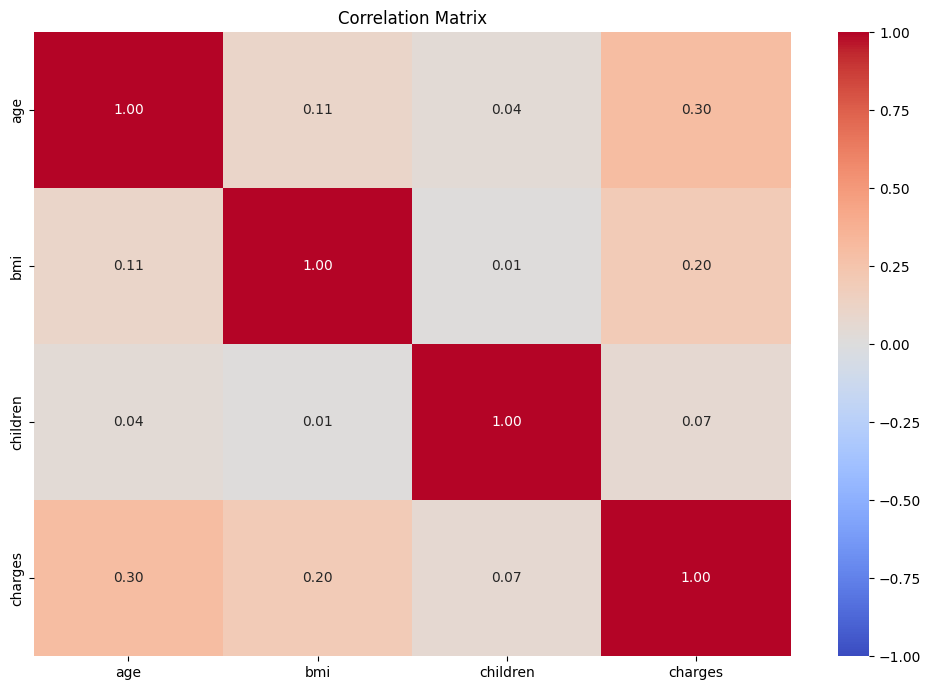

In [7]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[['age','bmi','children','charges']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('Correlation.png', dpi=100)
plt.show()

### Charges Berdasarkan Status Merokok

Ini adalah fitur yang paling berpengaruh terhadap biaya asuransi.

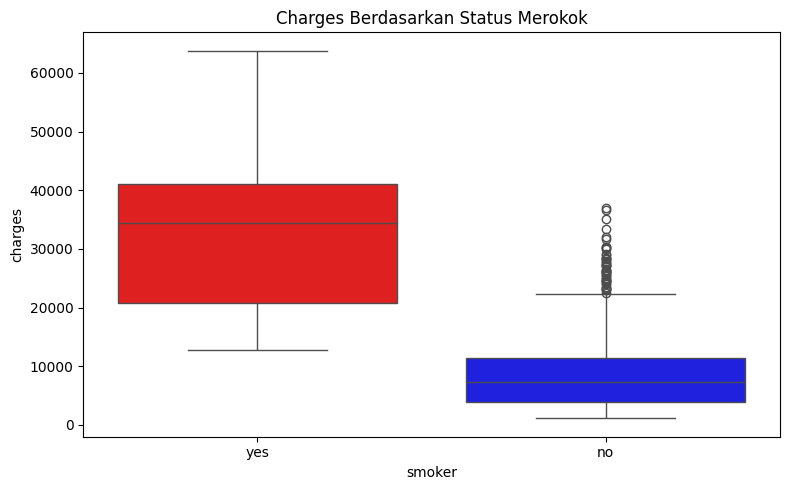

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='smoker', y='charges', hue='smoker',
            palette={'yes': 'red', 'no': 'blue'}, legend=False)
plt.title('Charges Berdasarkan Status Merokok')
plt.tight_layout()
plt.savefig('boxplot.png', dpi=100)
plt.show()

## 5. Preprocessing

In [9]:
X = df.drop(columns=['charges'])
y = df['charges']

numerik_cols = ['age','bmi','children']
nominal_cols = ['sex','smoker','region']

preprocessor = make_column_transformer(
    (StandardScaler(), numerik_cols),
    (OneHotEncoder(drop='first'), nominal_cols)
)

## 6. Latih & Bandingkan Model

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

daftar_model = {
    'LinearRegression' : LinearRegression(),
    'DecisionTree'      : DecisionTreeRegressor(random_state=42),
    'RandomForest'      : RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting'  : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

hasil = {}

for name, reg in daftar_model.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('regressor', reg)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    mae  = mean_absolute_error(y_test, pred)
    mse  = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, pred)

    hasil[name] = {'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2, 'pipeline': pipe, 'pred': pred}
    print(f'{name} | MAE = {mae:.2f} | MSE = {mse:.2f} | RMSE = {rmse:.2f} | R2 = {r2:.4f}')

LinearRegression | MAE = 4177.05 | MSE = 35478020.68 | RMSE = 5956.34 | R2 = 0.8069
DecisionTree | MAE = 2804.81 | MSE = 34953028.96 | RMSE = 5912.11 | R2 = 0.8098
RandomForest | MAE = 2663.33 | MSE = 22372575.46 | RMSE = 4729.97 | R2 = 0.8782
GradientBoosting | MAE = 2517.47 | MSE = 18218239.92 | RMSE = 4268.28 | R2 = 0.9009


In [11]:
model_terbaik = max(hasil, key=lambda k: hasil[k]['r2'])
print(f'Model terbaik = {model_terbaik}')

Model terbaik = GradientBoosting


## 7. Visualisasi Perbandingan Model

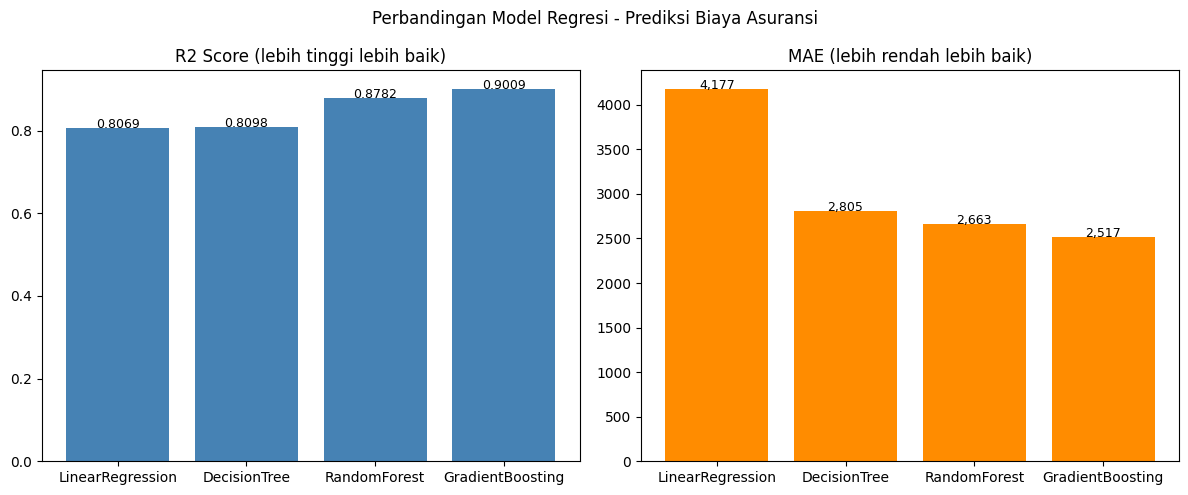

In [12]:
nama_model  = list(hasil.keys())
r2_scores   = [hasil[n]['r2']  for n in nama_model]
mae_scores  = [hasil[n]['mae'] for n in nama_model]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(nama_model, r2_scores, color='steelblue')
axes[0].set_title('R2 Score (lebih tinggi lebih baik)')
for i, v in enumerate(r2_scores):
    axes[0].text(i, v, f'{v:.4f}', ha='center', fontsize=9)

axes[1].bar(nama_model, mae_scores, color='darkorange')
axes[1].set_title('MAE (lebih rendah lebih baik)')
for i, v in enumerate(mae_scores):
    axes[1].text(i, v, f'{v:,.0f}', ha='center', fontsize=9)

plt.suptitle('Perbandingan Model Regresi - Prediksi Biaya Asuransi')
plt.tight_layout()
plt.savefig('Perbandingan_model.png', dpi=100)
plt.show()

## 8. Feature Importance

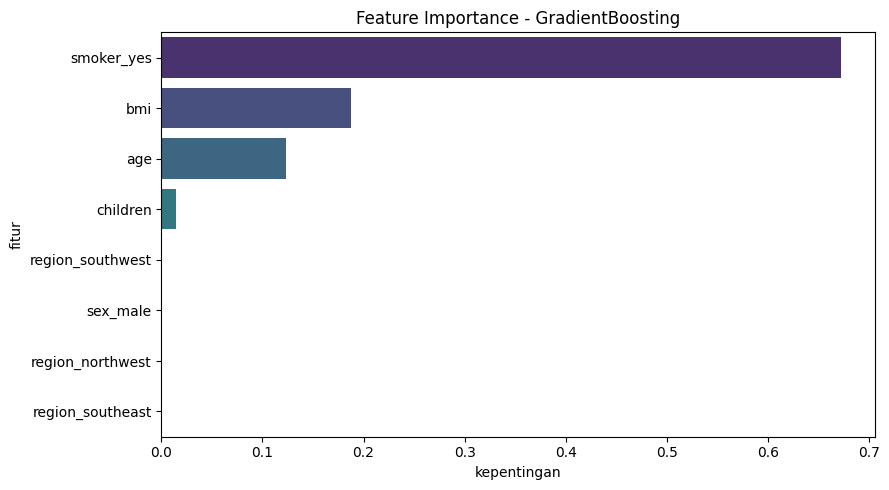

In [13]:
try:
    clf_step = hasil[model_terbaik]['pipeline'].named_steps['regressor']
    pre_step = hasil[model_terbaik]['pipeline'].named_steps['preprocessor']
    ohe_names = list(pre_step.named_transformers_['onehotencoder']
                     .get_feature_names_out(nominal_cols))
    semua_fitur = numerik_cols + ohe_names

    fi_df = (pd.DataFrame({'fitur': semua_fitur,
                           'kepentingan': clf_step.feature_importances_})
               .sort_values('kepentingan', ascending=False))

    plt.figure(figsize=(9, 5))
    sns.barplot(data=fi_df, x='kepentingan', y='fitur', hue='fitur',
                palette='viridis', legend=False)
    plt.title(f'Feature Importance - {model_terbaik}')
    plt.tight_layout()
    plt.savefig('feature_importances.png', dpi=100)
    plt.show()
except AttributeError:
    print(f'Feature Importance tidak tersedia untuk model {model_terbaik}')

## 9. Simpan Model

In [14]:
joblib.dump(hasil[model_terbaik]['pipeline'], 'model_insurance.pkl')
print('Model berhasil disimpan')

Model berhasil disimpan


## 10. Kesimpulan

- Model terbaik berdasarkan R² Score adalah **Gradient Boosting**, dengan R² ≈ 0.90 
  (mampu menjelaskan 90% variasi biaya asuransi).
- Fitur **status merokok** dan **umur** adalah dua faktor paling dominan dalam menentukan biaya asuransi.
- Faktor gender dan wilayah hampir tidak berpengaruh terhadap besarnya biaya.

**Implikasi:** Perusahaan asuransi dapat menggunakan status merokok dan umur sebagai indikator 
utama dalam menentukan premi, dibanding faktor demografis lain seperti gender atau lokasi.
